In [1]:
!pip list

Package                 Version
----------------------- -----------
asttokens               3.0.2
colorama                0.4.6
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.21
executing               2.2.1
fonttools               4.65.0
ipykernel               7.3.0
ipython                 9.17.1
ipython_pygments_lexers 1.1.1
jedi                    0.20.0
jupyter_client          8.10.0
jupyter_core            5.9.1
kiwisolver              1.5.1
matplotlib              3.11.1
matplotlib-inline       0.2.2
nest-asyncio2           1.7.2
numpy                   2.5.3
opencv-python           5.0.0.93
packaging               26.3
pandas                  3.0.5
parso                   0.8.7
pillow                  12.3.0
pip                     24.0
platformdirs            4.11.8
prompt_toolkit          3.0.53
psutil                  7.2.2
pure_eval               0.2.4
Pygments                2.21.0
pyparsing           


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import cv2
from matplotlib import pyplot as plt
import numpy as np 
import pandas as pd

import os

In [3]:
vid = cv2.VideoCapture(r"../data/Playlist1/01-Road traffic video for object recognition.mp4")
fps = vid.get(cv2.CAP_PROP_FPS)
print(f"FPS: {fps}")

FPS: 25.0


In [8]:
W, H = vid.get(cv2.CAP_PROP_FRAME_WIDTH), vid.get(cv2.CAP_PROP_FRAME_HEIGHT)
total = int(vid.get(cv2.CAP_PROP_FRAME_COUNT))
duration = int(total / fps)
print(f"Total Frames: {total}")
print(f"Clip Duration: {duration} seconds")
print(f"Width: {W}")
print(f"Height: {H}")
print(f"Res: {int(W)}x{int(H)}")

vid.release()

Total Frames: 51201
Clip Duration: 2048 seconds
Width: 1280.0
Height: 720.0
Res: 1280x720


In [8]:
# def load_video(vid_path):
#     cap = cv2.VideoCapture(vid_path)
#     frames = []
#     while True:
#         ret, frame = cap.read()
#         if not ret: break
#         # Convert BGR --> RGB
#         frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         frames.append(frame)
#     cap.release()
#     return frames 

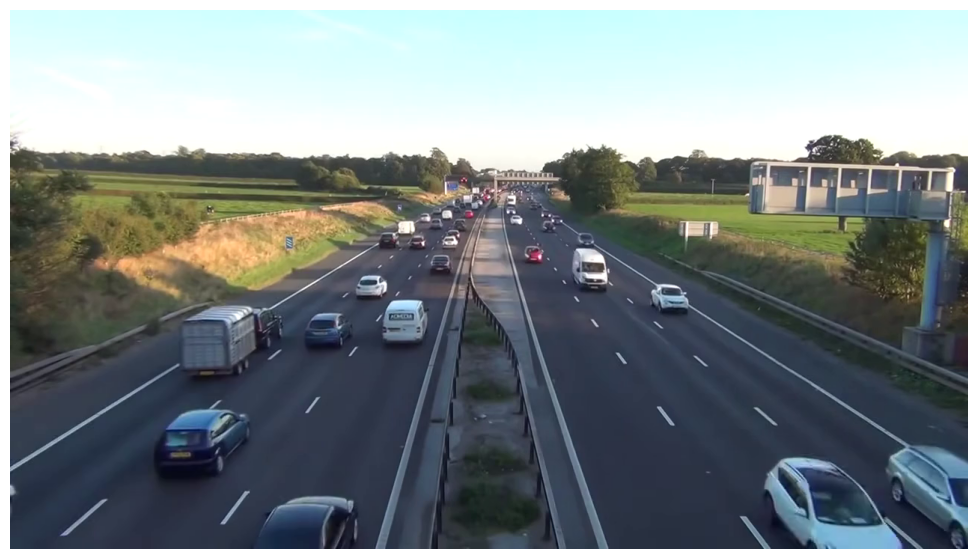

In [14]:
def get_frame(frame_idx, vid_cap):
    """For capturing a single frame specified by index"""
    vid_cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = vid_cap.read()
    # plt.imshow(frame)
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ret else None


cap = cv2.VideoCapture(r"../data/Playlist1/01-Road traffic video for object recognition.mp4")
fig1 = plt.figure(figsize=(14, 7))
plt.axis("off")
plt.imshow(get_frame(500, cap))

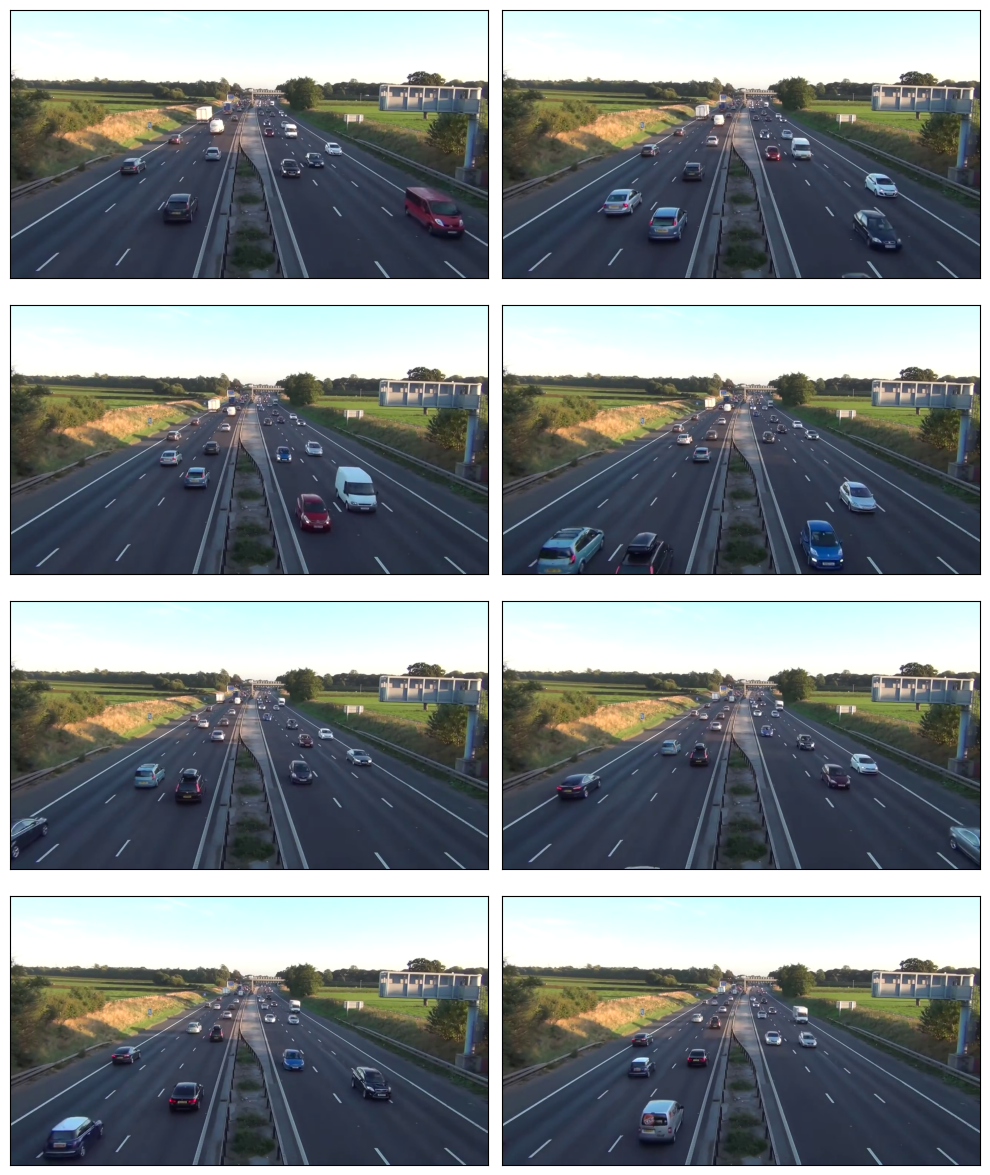

In [32]:
def show_frames(vidcap, start=0, num_frames=8, interval=1):
    """
    For displaying a grid of frames separated by a fixed interval.
    vidcap: OpenCV VideoCapture instance of the clip to be displayed
    start: Starting index of the VideoCapture pointer
    num_frames: Number of sequenced frames to display
    interval: Interval in seconds (frame_steps=0.5 means 0.5 sec interval for each frame)
    """
    
    fps = vidcap.get(cv2.CAP_PROP_FPS)
    frame_steps = int(fps*interval)
    frame_counts = int(vidcap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Ensure last frame does not exceed the clip
    window = frame_steps * (num_frames-1)
    last_frame = start+window
    if last_frame >= frame_counts:
        last_frame_idx = frame_counts-1  # this is 0-based
        start = last_frame_idx - window

    # Get the frames
    frames = []
    for idx in range(start, last_frame_idx+1, frame_steps):
        vidcap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = vidcap.read()
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)

    ncols = 2
    nrows = int(np.ceil(num_frames/2))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*3))
    for ax, frame in zip(axes.flat, frames):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(frame)
    plt.tight_layout()

cap = cv2.VideoCapture(r"../data/Playlist1/01-Road traffic video for object recognition.mp4")
show_frames(cap, start=5000)